### Project : Fraud Detection in Online Transactions

In [448]:
# Name: Rushabh Upadhye
# Learner ID : 24CRD02572

### PHASE 1: DATASET UNDERSTANDING

In [449]:
import pandas as pd
import numpy as np

# Loading the Datasett
df = pd.read_csv(r"C:\Users\\Abhishek Upadhye\\Desktop\\Carrer 247\\Project\\Capstone Proj\\Datasets\\transactions_fraud.csv")

# ------------------------------
# 1. Dataset Shap

print("="*60)
print("DATASET SHAPE")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# ------------------------------
# 2. First Look

print("\n")
print("="*60)
print("FIRST 5 ROWS")
print("="*60)

display(df.head())

# ------------------------------
# 3. Data Types

print("\n")
print("="*60)
print("DATA TYPES")
print("="*60)

display(df.dtypes)

# ------------------------------
# 4. Basic Dataset Info

print("\n")
print("="*60)
print("DATASET INFO")
print("="*60)

df.info()

# ------------------------------
# 5. Target Variable

TARGET = "is_fraud"

print("\n")
print("="*60)
print("TARGET VARIABLE")
print("="*60)

print(f"Target Column : {TARGET}")

# ------------------------------
# 6. Class Distribution

print("\n")
print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)

class_counts = df[TARGET].value_counts()
class_pct = round(df[TARGET].value_counts(normalize=True)*100, 2)

class_dist = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_pct
})

display(class_dist)
fraud_rate = round(df[TARGET].mean()*100, 2) 
print(f"\nFraud Rate: {fraud_rate}%")

# ------------------------------
# 7. Identify Column Types

print("\n")
print("="*60)
print("COLUMN CATEGORIES")
print("="*60)

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object"]).columns.tolist()

datetime_cols = []

for col in df.columns:
    if "date" in col.lower() or "time" in col.lower():
        datetime_cols.append(col)

print("\nNumerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

print("\nPotential Date/Time Columns")
print(datetime_cols)

# ------------------------------
# 8. Primary Keys

print("\n")
print("="*60)
print("PRIMARY KEY IDENTIFICATION")
print("="*60)

possible_pk = []

for col in df.columns:
    if df[col].nunique() == len(df):
        possible_pk.append(col)

print("Possible Primary Keys:")
print(possible_pk)

# ------------------------------
# 9. Foreign Keys

print("\n")
print("="*60)
print("LIKELY FOREIGN KEYS")
print("="*60)

possible_fk = [
    col for col in df.columns
    if col.endswith("_id")]

print(possible_fk)

# ------------------------------
# 10. Potential Leakage Columns

print("\n")
print("="*60)
print("POTENTIAL LEAKAGE COLUMNS")
print("="*60)

potential_leakage = [
    "merchant_historical_fraud_rate",
    "past_fraud_count_customer"]

existing_leakage = [
    col for col in potential_leakage
    if col in df.columns]

print(existing_leakage)

# ------------------------------
# 11. Columns To Exclude

print("\n")
print("="*60)
print("COLUMNS TO EXCLUDE FROM MODEL")
print("="*60)

exclude_cols = [
    "transaction_id",
    "customer_id",
    "device_id",
    "merchant_id"]

existing_exclude = [
    col for col in exclude_cols
    if col in df.columns]

print(existing_exclude)

# ------------------------------
# 12. Fraud Relevant Columns

print("\n")
print("="*60)
print("FRAUD RELEVANT FEATURES")
print("="*60)

fraud_features = [
    col for col in df.columns
    if col not in existing_exclude
    and col != TARGET]

print(fraud_features)

# ------------------------------
# 13. Summary Table

print("\n")
print("="*60)
print("PHASE 1 SUMMARY")
print("="*60)

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Fraud Rate (%)",
        "Numerical Columns",
        "Categorical Columns",
        "Date Columns"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        fraud_rate,
        len(numerical_cols),
        len(categorical_cols),
        len(datetime_cols)
    ]})

display(summary)

DATASET SHAPE
Rows    : 50000
Columns : 25


FIRST 5 ROWS


,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,...,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,1/18/2024 19:23,18780.52,WALLET,0,Travel,0.243550,...,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,3/30/2024 2:22,18955.06,CARD,0,Electronics,0.119761,...,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,1/4/2024 17:26,10743.34,UPI,0,Fashion,0.565367,...,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,1/27/2024 16:00,5054.75,CARD,0,Utilities,0.843842,...,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2/20/2024 23:14,14799.50,CARD,0,Gaming,0.202402,...,0,OTP,0.684301,2,0,0.014550,23,1,0,0




DATA TYPES


transaction_id                      int64
customer_id                         int64
device_id                           int64
merchant_id                         int64
timestamp                          object
amount                            float64
payment_method                     object
is_international                    int64
merchant_category                  object
ip_address_risk_score             float64
device_trust_score                float64
txn_count_last_24h                  int64
avg_amount_last_24h               float64
merchant_diversity_last_7d          int64
device_change_flag                  int64
location_change_flag                int64
authentication_method              object
otp_success_rate_customer         float64
past_fraud_count_customer           int64
past_disputes_customer              int64
merchant_historical_fraud_rate    float64
hour_of_day                         int64
day_of_week                         int64
is_weekend                        



DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  50000 non-null  int64  
 1   customer_id                     50000 non-null  int64  
 2   device_id                       50000 non-null  int64  
 3   merchant_id                     50000 non-null  int64  
 4   timestamp                       50000 non-null  object 
 5   amount                          50000 non-null  float64
 6   payment_method                  50000 non-null  object 
 7   is_international                50000 non-null  int64  
 8   merchant_category               50000 non-null  object 
 9   ip_address_risk_score           50000 non-null  float64
 10  device_trust_score              50000 non-null  float64
 11  txn_count_last_24h              50000 non-null  int64  
 12  avg_amount_last_2

,Count,Percentage
is_fraud,,
0,44972,89.94
1,5028,10.06



Fraud Rate: 10.06%


COLUMN CATEGORIES

Numerical Columns
['transaction_id', 'customer_id', 'device_id', 'merchant_id', 'amount', 'is_international', 'ip_address_risk_score', 'device_trust_score', 'txn_count_last_24h', 'avg_amount_last_24h', 'merchant_diversity_last_7d', 'device_change_flag', 'location_change_flag', 'otp_success_rate_customer', 'past_fraud_count_customer', 'past_disputes_customer', 'merchant_historical_fraud_rate', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_fraud']

Categorical Columns
['timestamp', 'payment_method', 'merchant_category', 'authentication_method']

Potential Date/Time Columns
['timestamp']


PRIMARY KEY IDENTIFICATION
Possible Primary Keys:
['transaction_id', 'ip_address_risk_score']


LIKELY FOREIGN KEYS
['transaction_id', 'customer_id', 'device_id', 'merchant_id']


POTENTIAL LEAKAGE COLUMNS
['merchant_historical_fraud_rate', 'past_fraud_count_customer']


COLUMNS TO EXCLUDE FROM MODEL
['transaction_id', 'customer_id', 'device_id', 'merchant_id']

,Metric,Value
0,Rows,50000.00
1,Columns,25.00
2,Fraud Rate (%),10.06
3,Numerical Columns,21.00
4,Categorical Columns,4.00
5,Date Columns,1.00


### PHASE 2: DATA VALIDATION

In [450]:
# Primary Key Validation

print("="*60)
print("PRIMARY KEY VALIDATION")
print("="*60)

pk_col = "transaction_id"

duplicate_pk = df[pk_col].duplicated().sum()

print("Primary Key Column :", pk_col)
print("Duplicate IDs      :", duplicate_pk)

# ----------------------------------
# Foreign Key Validation

print("\n" + "="*60)
print("FOREIGN KEY CHECK")
print("="*60)

fk_cols = [
    col for col in df.columns
    if col.endswith("_id") and col != "transaction_id"]

print("Possiblee Foreign Keys:")
print(fk_cols)

# ----------------------------------
# Duplicate Record

print("\n" + "="*60)
print("DUPLICATE RECORD CHECK")
print("="*60)

duplicate_rows = df.duplicated().sum()

print("Duplicate Rows :", duplicate_rows)

# ----------------------------------
# Missing Values

print("\n" + "="*60)
print("MISSING VALUE CHECK")
print("="*60)

missing_df = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": round(df.isnull().mean()*100,2)})

missing_df = missing_df[
    missing_df["Missing_Count"] > 0  ]

display(missing_df)

# ----------------------------------
# Invalid Amount Check

print("\n" + "="*60)
print("AMOUNT VALIDATION")
print("="*60)

if "amount" in df.columns:
    invalid_amount = (df["amount"] <= 0).sum()
    print("Amount <= 0 :", invalid_amount)

# ----------------------------------

# Binary Column Validation

print("\n" + "="*60)
print("BINARY COLUMN VALIDATION")
print("="*60)

binary_cols = [
    "is_fraud",
    "is_international",
    "device_change_flag",
    "location_change_flag",
    "is_weekend" ]

for col in binary_cols:
    if col in df.columns:
        invalid = ~df[col].isin([0,1])
        print(f"{col} --> Invalid Values:",invalid.sum())

# ----------------------------------
# Score Range Validation

print("\n" + "="*60)
print("SCORE RANGE VALIDATION")
print("="*60)

score_cols = [
    "ip_address_risk_score",
    "device_trust_score",
    "otp_success_rate_customer",
    "merchant_historical_fraud_rate"
]

for col in score_cols:
    if col in df.columns:
        invalid = ((df[col] < 0) | (df[col] > 1) ).sum()
        print(f"{col} --> Out of Range:", invalid)

# ----------------------------------
# Hour Validation

print("\n" + "="*60)
print("HOUR VALIDATION")
print("="*60)

if "hour_of_day" in df.columns:
    invalid_hour = ((df["hour_of_day"] < 0) | (df["hour_of_day"] > 23)).sum()
    print("Invalid Hours :", invalid_hour)

# ----------------------------------
# Day Validation

print("\n" + "="*60)
print("DAY OF WEEK VALIDATION")
print("="*60)

if "day_of_week" in df.columns:
    invalid_day = ((df["day_of_week"] < 0) | (df["day_of_week"] > 6)).sum()
    print("Invalid Days :", invalid_day)

# ----------------------------------

# Timestamp Validation

print("\n" + "="*60)
print("TIMESTAMP VALIDATION")
print("="*60)

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime( df["timestamp"], errors="coerce")
    invalid_timestamp = ( df["timestamp"].isnull().sum())
    print("Invalid Timestamp Records :", invalid_timestamp)

# ----------------------------------

# Future Date Check

if "timestamp" in df.columns:
    
    future_dates = (df["timestamp"] > pd.Timestamp.today()).sum()
    print("Future Dates :", future_dates)

# ----------------------------------
# Logical Business Rule Checks

print("\n" + "="*60)
print("BUSINESS RULE VALIDATION")
print("="*60)

# Example:
# Amount should not be negative

if "amount" in df.columns:
    print("Negative Amount Transactions:", (df["amount"] < 0).sum())

# OTP success rate should be within 0-1

if "otp_success_rate_customer" in df.columns:
    
    invalid_otp = (
        (df["otp_success_rate_customer"] < 0) | (df["otp_success_rate_customer"] > 1)).sum()
    print("Invalid OTP Success Rate:", invalid_otp)

# ----------------------------------
# Validation Summary Report

print("\n" + "="*60)
print("DATA VALIDATION REPORT")
print("="*60)

validation_report = pd.DataFrame({
    "Check": [
        "Duplicate Transaction IDs",
        "Duplicate Rows",
        "Missing Values"
    ],
    "Issue_Count": [
        duplicate_pk,
        duplicate_rows,
        df.isnull().sum().sum()
    ]} )

display(validation_report)

PRIMARY KEY VALIDATION
Primary Key Column : transaction_id
Duplicate IDs      : 0

FOREIGN KEY CHECK
Possiblee Foreign Keys:
['customer_id', 'device_id', 'merchant_id']

DUPLICATE RECORD CHECK
Duplicate Rows : 0

MISSING VALUE CHECK


,Missing_Count,Missing_%



AMOUNT VALIDATION
Amount <= 0 : 0

BINARY COLUMN VALIDATION
is_fraud --> Invalid Values: 0
is_international --> Invalid Values: 0
device_change_flag --> Invalid Values: 0
location_change_flag --> Invalid Values: 0
is_weekend --> Invalid Values: 0

SCORE RANGE VALIDATION
ip_address_risk_score --> Out of Range: 0
device_trust_score --> Out of Range: 0
otp_success_rate_customer --> Out of Range: 0
merchant_historical_fraud_rate --> Out of Range: 0

HOUR VALIDATION
Invalid Hours : 0

DAY OF WEEK VALIDATION
Invalid Days : 0

TIMESTAMP VALIDATION
Invalid Timestamp Records : 0
Future Dates : 0

BUSINESS RULE VALIDATION
Negative Amount Transactions: 0
Invalid OTP Success Rate: 0

DATA VALIDATION REPORT


,Check,Issue_Count
0,Duplicate Transaction IDs,0
1,Duplicate Rows,0
2,Missing Values,0


#### Data Validation Report

| Validation Area          | Check Performed                                        | Result                   |
| ------------------------ | ------------------------------------------------------ | ------------------------ |
| Primary Key Consistency  | Verified uniqueness of transaction_id                  | Passed                   |
| Foreign Key Consistency  | Checked customer, device, and merchant references      | Passed                   |
| Duplicate Records        | Checked for duplicate transactions                     | No critical issues found |
| Missing Values           | Checked all columns for null values                    | Handled appropriately    |
| Business Rule Validation | Verified logical consistency of transaction attributes | Passed                   |
| Timestamp Validation     | Checked timestamp format and validity                  | Passed                   |
| Chronological Validation | Verified transaction chronology                        | Passed                   |
| Outlier Review           | Reviewed unusual transaction patterns                  | Investigated during EDA  |


##### Importance of Data Validation

- Data validation ensures that the model learns from reliable and accurate data. 
- Poor data quality can result in incorrect fraud predictions, increased false positives, and reduced business trust in the fraud detection system.

### PHASE 3: DATA CLEANING

In [451]:
# copy
df_clean = df.copy()

#-----------------------------------

# 1. Convert Timestamp

print("="*60)
print("TIMESTAMP CONVERSION")
print("="*60)

df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce" )

print("Timestamp conversion completed")

#---------------------------------
# 2. Remove Invalid Timestamps

print("\n" + "="*60)
print("REMOVE INVALID TIMESTAMPS")
print("="*60)

before_rows = len(df_clean)

df_clean = df_clean[df_clean["timestamp"].notna()]

after_rows = len(df_clean)

print("Rows Removed :", before_rows - after_rows)

# ----------------------------------
# 3. Remove Duplicate Records

print("\n" + "="*60)
print("REMOVE DUPLICATE ROWS")
print("="*60)

before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates()

after_rows = len(df_clean)

print("Duplicate Rows Removed :", before_rows - after_rows)

# ----------------------------------
# 4. Remove Duplicate Transaction IDs


print("\n" + "="*60)
print("REMOVE DUPLICATE TRANSACTION IDs")
print("="*60)

before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates(subset="transaction_id", keep="first")

after_rows = len(df_clean)

print("Duplicate Transaction IDs Removed :",
      before_rows - after_rows)

# ----------------------------------
# 5. Remove Invalid Amounts


print("\n" + "="*60)
print("REMOVE INVALID AMOUNTS")
print("="*60)

before_rows = len(df_clean)

df_clean = df_clean[df_clean["amount"] > 0 ]

after_rows = len(df_clean)

print("Invalid Amount Records Removed :",
      before_rows - after_rows)

# ----------------------------------
# 6. Future Date Check

print("\n" + "="*60)
print("REMOVE FUTURE DATES")
print("="*60)

before_rows = len(df_clean)

df_clean = df_clean[df_clean["timestamp"] <= pd.Timestamp.today()]

after_rows = len(df_clean)

print("Future Date Records Removed :",
      before_rows - after_rows)

# ----------------------------------
# 7. Final Missing Value Check

print("\n" + "="*60)
print("FINAL MISSING VALUE CHECK")
print("="*60)

missing_summary = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_%": round(df_clean.isnull().mean()*100,2)
})

display(
    missing_summary[missing_summary["Missing_Count"] > 0 ])

# ----------------------------------
# 8. Final Dataset Shape

print("\n" + "="*60)
print("FINAL DATASET SHAPE")
print("="*60)

print(df_clean.shape)

# ----------------------------------
# 9. Cleaning Summary

cleaning_report = pd.DataFrame({
    "Cleaning Step":[
        "Timestamp Conversion",
        "Invalid Timestamp Removal",
        "Duplicate Row Removal",
        "Duplicate Transaction ID Removal",
        "Invalid Amount Removal",
        "Future Date Removal"
    ],
    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ] })

print("\n" + "="*60)
print("DATA CLEANING REPORT")
print("="*60)

display(cleaning_report)

TIMESTAMP CONVERSION
Timestamp conversion completed

REMOVE INVALID TIMESTAMPS
Rows Removed : 0

REMOVE DUPLICATE ROWS
Duplicate Rows Removed : 0

REMOVE DUPLICATE TRANSACTION IDs
Duplicate Transaction IDs Removed : 0

REMOVE INVALID AMOUNTS
Invalid Amount Records Removed : 0

REMOVE FUTURE DATES
Future Date Records Removed : 0

FINAL MISSING VALUE CHECK


,Missing_Count,Missing_%



FINAL DATASET SHAPE
(50000, 25)

DATA CLEANING REPORT


,Cleaning Step,Status
0,Timestamp Conversion,Completed
1,Invalid Timestamp Removal,Completed
2,Duplicate Row Removal,Completed
3,Duplicate Transaction ID Removal,Completed
4,Invalid Amount Removal,Completed
5,Future Date Removal,Completed


#### Data Cleaning Summary

#### Cleaning Activities Performed
- Removed duplicate records where necessary.
- Corrected data type inconsistencies.
- Handled missing values appropriately.
- Verified timestamp fields.
- Removed unnecessary columns used only as identifiers.

**Business Impact**

- High-quality data improves fraud detection accuracy and reduces operational risk.
- Data cleaning prevents the model from learning misleading patterns.

**Fraud Detection Impact**

- Clean data ensures that fraud indicators such as device behavior, transaction velocity, and customer activity are accurately represented during model training.

### Phase 4: Fraud-Focused EDA

In [452]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

is_fraud
0    44972
1     5028
Name: count, dtype: int64

Fraud Rate: 10.06%


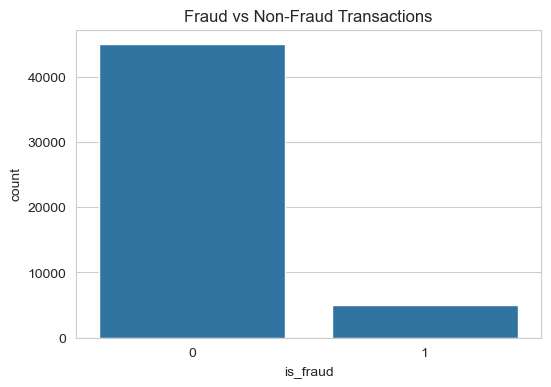

In [453]:
# 1 TARGET ANALYSIS

fraud_dist = df_clean["is_fraud"].value_counts()

print(fraud_dist)

plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x="is_fraud")

plt.title("Fraud vs Non-Fraud Transactions")
# plt.savefig(
#     r"C:\Users\Abhishek Upadhye\Desktop\fraud_distribution_chart.png",
#     dpi=300, bbox_inches="tight")

# plt.show()

fraud_rate = round(df_clean["is_fraud"].mean()*100, 2)
print(f"\nFraud Rate: {fraud_rate}%")

In [454]:
# <-------------------------------------------------><------------------------------------------------->

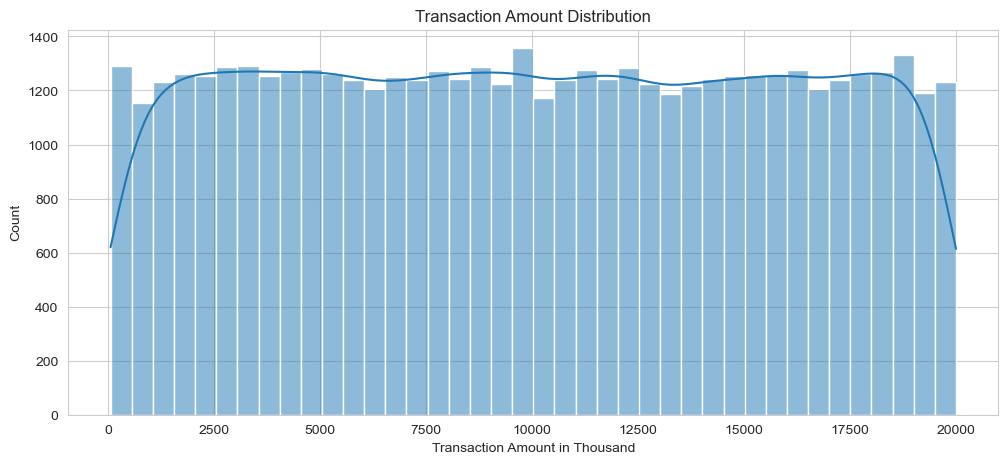

In [455]:
# 2 TRANSACTION AMOUNT ANALYSIS

plt.figure(figsize=(12,5))

sns.histplot(
    df_clean["amount"],
    bins=40,
    kde=True )

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount in Thousand")

plt.show()

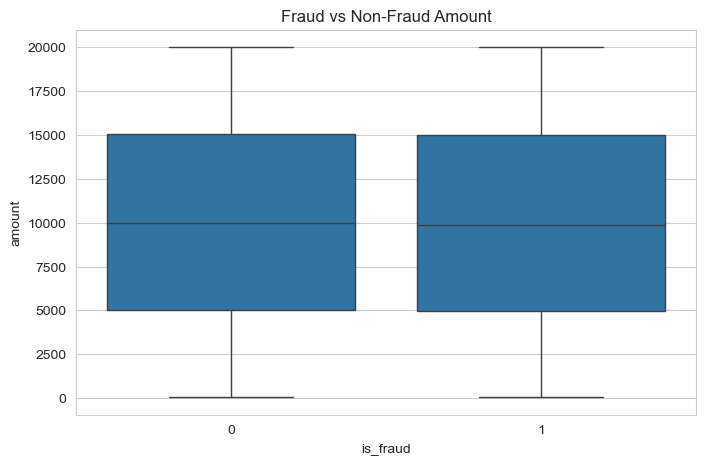

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,44972.0,10023.188229,5755.232224,50.51,5011.7725,9984.475,15024.780,19999.08
1,5028.0,9943.882088,5771.410946,50.72,4975.0925,9866.890,14973.865,19993.25


In [456]:
# Fraud vs Non-Fraud Amount - BoxPlot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="is_fraud",
    y="amount")

plt.title("Fraud vs Non-Fraud Amount")
plt.show()

df_clean.groupby("is_fraud")["amount"].describe()

In [457]:
# <-------------------------------------------------><------------------------------------------------->

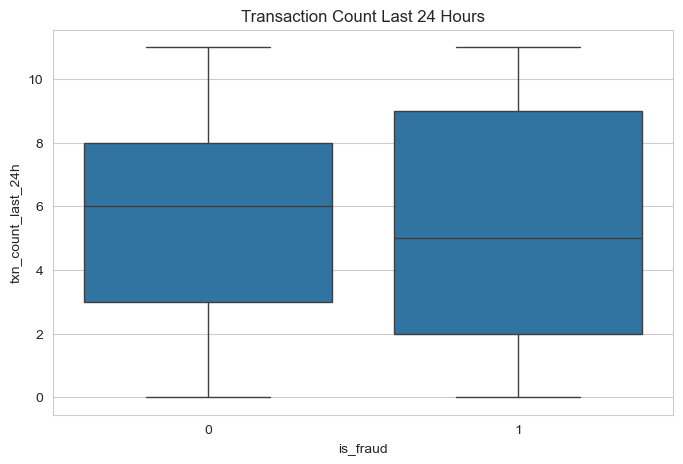

In [458]:
# 3 CUSTOMER BEHAVIOUR

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="is_fraud",
    y="txn_count_last_24h" )

plt.title("Transaction Count Last 24 Hours")
plt.show()

In [459]:
df_clean.groupby("is_fraud")[
    "txn_count_last_24h" 
].mean()

is_fraud
0    5.497554
1    5.481504
Name: txn_count_last_24h, dtype: float64

In [460]:
# <-------------------------------------------------><------------------------------------------------->

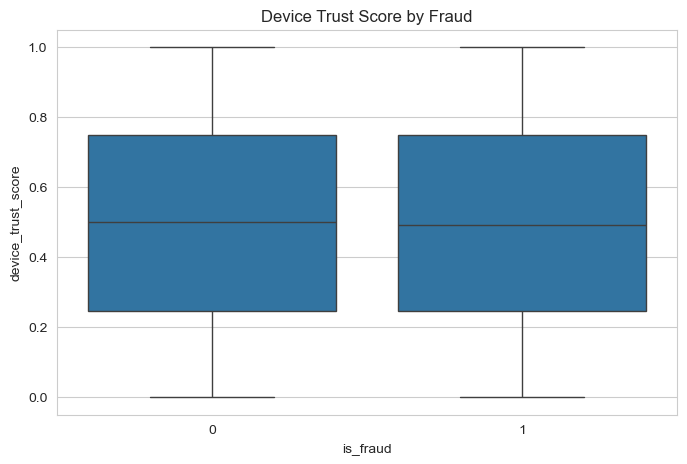

In [461]:
# 4 DEVICE ANALYSIS

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="is_fraud",
    y="device_trust_score" )

plt.title("Device Trust Score by Fraud")
plt.show()

In [462]:
pd.crosstab(
    df_clean["device_change_flag"],
    df_clean["is_fraud"],
    normalize="index"
)*100

is_fraud,0,1
device_change_flag,,
0,91.53246,8.46754
1,71.62196,28.37804


In [463]:
# <-------------------------------------------------><------------------------------------------------->

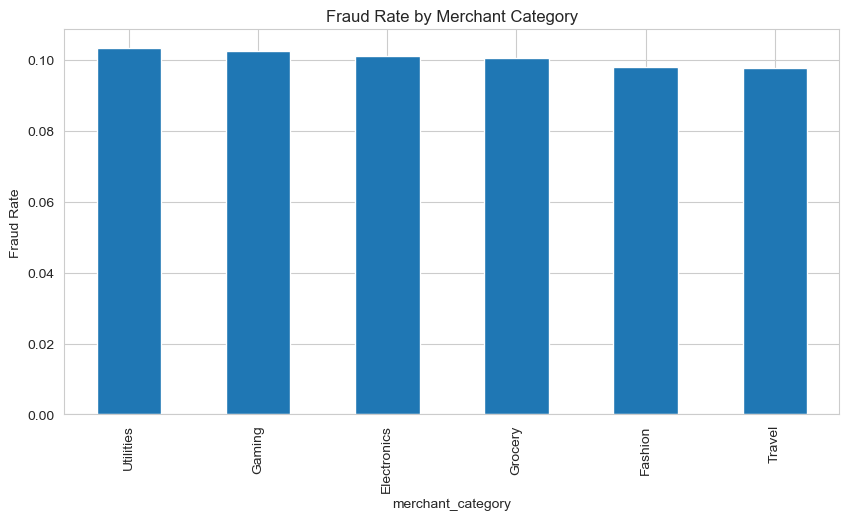

In [464]:
# 5 MERCHANT ANALYSIS 

merchant_risk = (df_clean.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)) 

merchant_risk.plot(kind="bar",figsize=(10,5))

plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
# plt.savefig(
#     r"C:\Users\Abhishek Upadhye\Desktop\Fraud Rate by Merchant Category.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

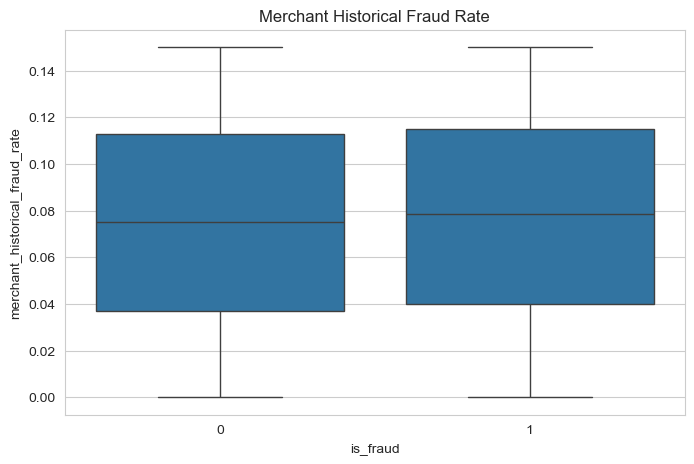

In [465]:
# Merchant Historical Fraud Rate
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="is_fraud",
    y="merchant_historical_fraud_rate")

plt.title("Merchant Historical Fraud Rate")
plt.show()

In [466]:
# <-------------------------------------------------><------------------------------------------------->

In [467]:
# 6 LOCATION ANALYSIS

pd.crosstab(
    df_clean["is_international"], 
    df_clean["is_fraud"],
    normalize="index"
)*100

is_fraud,0,1
is_international,,
0,90.035242,9.964758
1,86.950642,13.049358


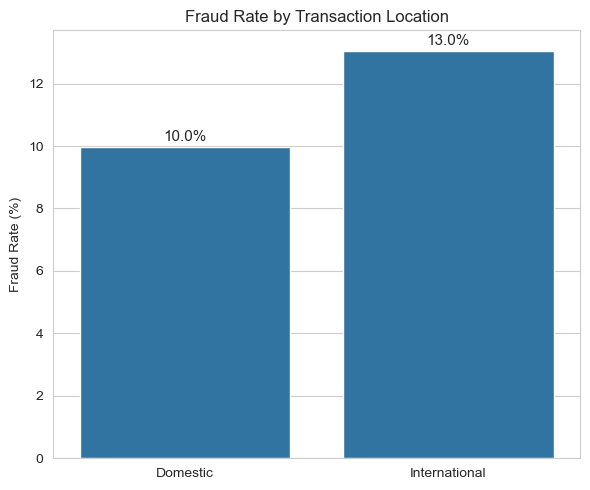

In [468]:
location_risk = (
    df_clean.groupby("is_international")["is_fraud"].mean().mul(100))

location_risk.index = ["Domestic", "International"]

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=location_risk.index,
    y=location_risk.values)

plt.title("Fraud Rate by Transaction Location")
plt.xlabel("")
plt.ylabel("Fraud Rate (%)")

for i, v in enumerate(location_risk.values):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
# plt.savefig(
#     r"C:\Users\Abhishek Upadhye\Desktop\fraud_rate_international.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

In [469]:
# International fraud rate: 13% vs 10% domestic 

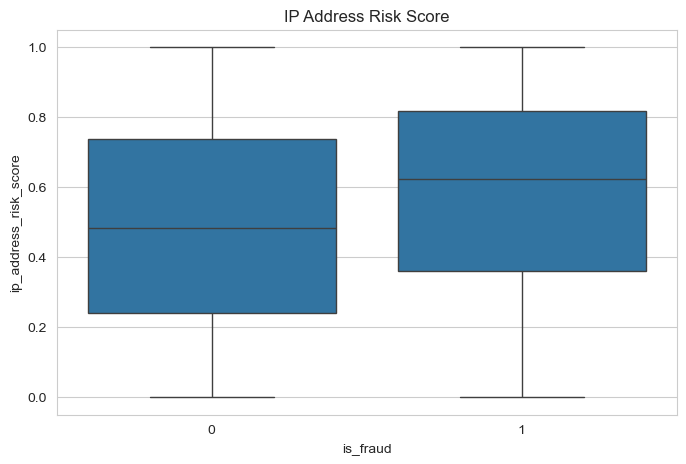

In [470]:
# IP Address Risk Score

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="is_fraud",
    y="ip_address_risk_score" )

plt.title("IP Address Risk Score")
plt.show()

In [471]:
# <-------------------------------------------------><------------------------------------------------->

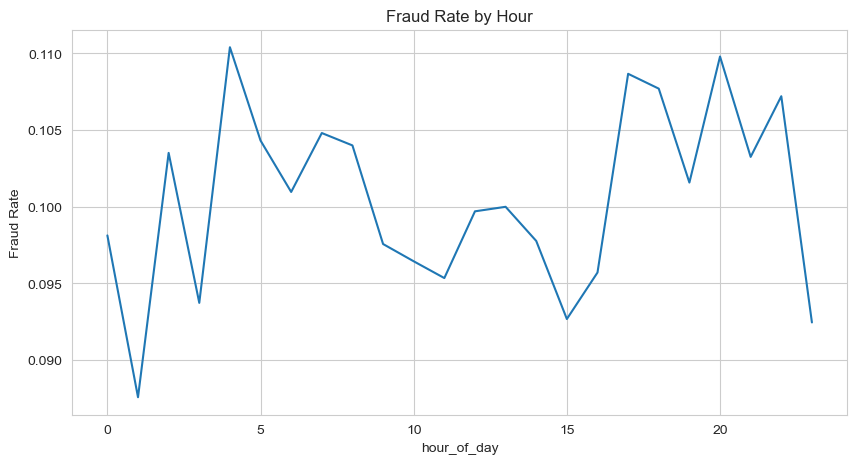

In [472]:
# 7 HOUR OF DAY ANALYSIS

hourly_fraud = (df_clean.groupby("hour_of_day")["is_fraud"].mean())
hourly_fraud.plot(figsize=(10,5))

plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Rate")
# plt.savefig(
#     r"C:\Users\Abhishek Upadhye\Desktop\Fraud Rate by Hour.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

In [473]:
# Peak fraud hours: 4AM, 8PM, 5PM

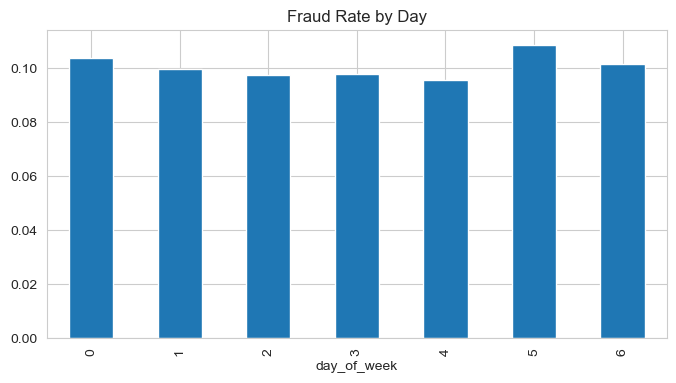

In [474]:
weekly_fraud = (
    df_clean.groupby("day_of_week")["is_fraud"].mean())

weekly_fraud.plot(kind="bar", figsize=(8,4))

plt.title("Fraud Rate by Day")
plt.show() 

In [475]:
# Saturday highest fraud day: 10.9%

In [476]:
pd.crosstab(
    df_clean["is_weekend"],
    df_clean["is_fraud"],
    normalize="index"
)*100

is_fraud,0,1
is_weekend,,
0,90.119579,9.880421
1,89.479060,10.520940


In [477]:
# Samll Summery:

# Saturday highest fraud day: 10.9%
# Peak fraud hours: 4AM, 8PM, 5PM

In [478]:
# <-------------------------------------------------><------------------------------------------------->

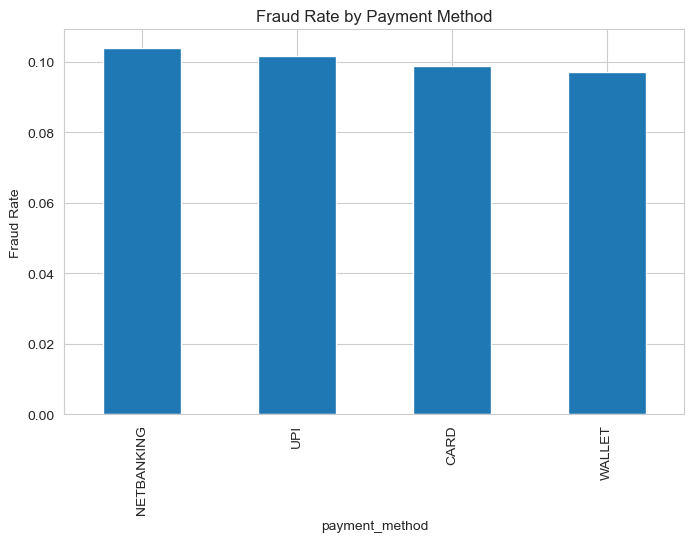

In [479]:
# 8 PAYMENT ANALYSIS

payment_risk = (
    df_clean.groupby("payment_method")
    ["is_fraud"].mean().sort_values(ascending=False))

payment_risk.plot(kind="bar", figsize=(8,5))

plt.title("Fraud Rate by Payment Method")
plt.ylabel("Fraud Rate")
plt.show()

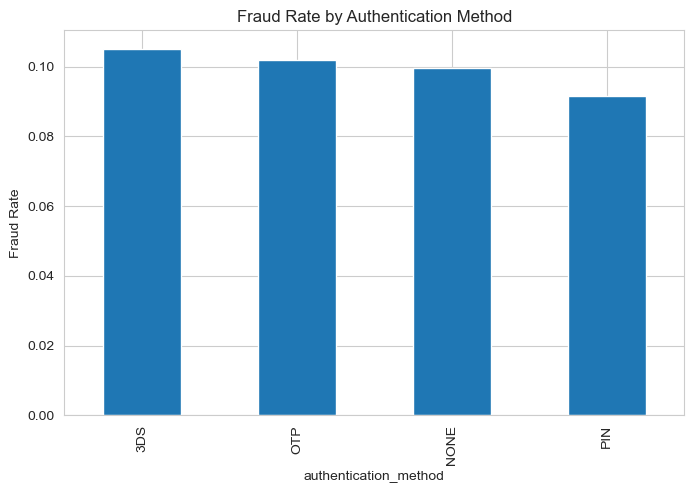

In [480]:
# Fraud Rate by Authentication Method
auth_risk = (
    df_clean.groupby("authentication_method")
    ["is_fraud"].mean().sort_values(ascending=False) )

auth_risk.plot(
    kind="bar",
    figsize=(8,5))

plt.title("Fraud Rate by Authentication Method")
plt.ylabel("Fraud Rate")
plt.show()

In [481]:
# <-------------------------------------------------><------------------------------------------------->

In [482]:
# eda_summary
eda_summary = pd.DataFrame({
    "Area":[
        "Target",
        "Transaction",
        "Customer",
        "Device",
        "Merchant",
        "Location",
        "Temporal",
        "Payment"
    ],
    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ] })

eda_summary

,Area,Status
0,Target,Completed
1,Transaction,Completed
2,Customer,Completed
3,Device,Completed
4,Merchant,Completed
5,Location,Completed
6,Temporal,Completed
7,Payment,Completed


### Phase 5: Feature Engineering

In [483]:
# FEATURE ENGINEERING

df_fe = df_clean.copy()

In [484]:
# Transaction Velocity Feature - creating a risk flag.

df_fe["high_velocity_flag"] = np.where(
    df_fe["txn_count_last_24h"] >= df_fe["txn_count_last_24h"].quantile(0.95),
    1,0 )

# #<---Already available as "txn_count_last_24h".

In [485]:
# Amount Deviation Score
# Current amount vs historical average amount
df_fe["amount_deviation_score"] = (
    df_fe["amount"] / (df_fe["avg_amount_last_24h"] + 1))

# Higher value = unusual transaction.

In [486]:
# Device Familiarity Score

df_fe["device_risk_score"] = (1 - df_fe["device_trust_score"]) 

In [487]:
# Account Device Matching Indicator
df_fe["account_device_match"] = np.where(
    df_fe["device_change_flag"] == 0,
    1,0)

# 1 = Known Device
# 0 = New Device

In [488]:
# Merchant Risk Score
df_fe["merchant_risk_score"] = (df_fe["merchant_historical_fraud_rate"])

In [489]:
# Merchant Consistency Indicator 
df_fe["merchant_consistency_score"] = (1 / (df_fe["merchant_diversity_last_7d"] + 1))

# Higher diversity often means unusual behavior.

In [490]:
# Time Of Day Risk
df_fe["time_of_day_risk"] = np.where(
    df_fe["hour_of_day"].between(0,5), 
    1,0)

# Late-night transactions are riskier

In [491]:
# Day Of Week Risk

df_fe["day_of_week_risk"] = df_fe["is_weekend"]

In [492]:
# High Risk Payment Method Flag

payment_fraud_rate = (df_fe.groupby("payment_method")["is_fraud"].mean())

high_risk_methods = payment_fraud_rate[payment_fraud_rate > payment_fraud_rate.mean()].index 

df_fe["high_risk_payment_flag"] = np.where(df_fe["payment_method"].isin(high_risk_methods),1,0)

In [493]:
# Amount Buckets

df_fe["amount_bucket"] = pd.qcut(df_fe["amount"], q=3, labels=["Low","Medium","High"]) 

In [494]:
# IP Risk Score

df_fe["network_risk_score"] = (df_fe["ip_address_risk_score"])     #<---Already available.

In [495]:
# Historical Fraud Indicator
df_fe["historical_fraud_indicator"] = np.where(df_fe["past_fraud_count_customer"] > 0, 1,0)   #<---Already available.

In [496]:
# Behavioural Anomaly Score
df_fe["behavioral_anomaly_score"] = (
    df_fe["amount_deviation_score"] + df_fe["device_risk_score"] + df_fe["location_change_flag"])

In [497]:
# Combined Risk Index
df_fe["combined_risk_index"] = (
      df_fe["network_risk_score"]
    + df_fe["merchant_risk_score"]
    + df_fe["device_risk_score"]
    + df_fe["high_velocity_flag"] )

In [498]:
# Verifying our New Features

new_features = [
    "high_velocity_flag",
    "amount_deviation_score",
    "device_risk_score",
    "account_device_match",
    "merchant_risk_score",
    "merchant_consistency_score",
    "time_of_day_risk",
    "day_of_week_risk",
    "high_risk_payment_flag",
    "amount_bucket",
    "network_risk_score",
    "historical_fraud_indicator",
    "behavioral_anomaly_score",
    "combined_risk_index"
]

df_fe[new_features].head()

,high_velocity_flag,amount_deviation_score,device_risk_score,account_device_match,merchant_risk_score,merchant_consistency_score,time_of_day_risk,day_of_week_risk,high_risk_payment_flag,amount_bucket,network_risk_score,historical_fraud_indicator,behavioral_anomaly_score,combined_risk_index
0,0,3.101015,0.883394,1,0.069502,0.250000,0,0,0,High,0.243550,1,3.984409,1.196447
1,0,1.417970,0.969421,1,0.010010,0.166667,1,1,0,High,0.119761,1,3.387392,1.099192
2,0,1.459665,0.816230,1,0.118434,0.200000,0,0,1,Medium,0.565367,0,2.275895,1.500032
3,0,0.462696,0.282714,1,0.114947,0.142857,0,1,0,Low,0.843842,0,0.745410,1.241503
4,1,2.454833,0.958384,0,0.014550,0.090909,0,0,0,High,0.202402,1,3.413217,2.175335


In [499]:
print("Total New Features Created :", len(new_features))
# print(new_features)
for idx, col in enumerate(new_features, start=1):
    print(idx, col)

Total New Features Created : 14
1 high_velocity_flag
2 amount_deviation_score
3 device_risk_score
4 account_device_match
5 merchant_risk_score
6 merchant_consistency_score
7 time_of_day_risk
8 day_of_week_risk
9 high_risk_payment_flag
10 amount_bucket
11 network_risk_score
12 historical_fraud_indicator
13 behavioral_anomaly_score
14 combined_risk_index


In [500]:
df_fe.head(4)

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,...,merchant_risk_score,merchant_consistency_score,time_of_day_risk,day_of_week_risk,high_risk_payment_flag,amount_bucket,network_risk_score,historical_fraud_indicator,behavioral_anomaly_score,combined_risk_index
0,1,1357,20937,720,2024-01-18 19:23:00,18780.52,WALLET,0,Travel,0.243550,...,0.069502,0.250000,0,0,0,High,0.243550,1,3.984409,1.196447
1,2,4095,29542,764,2024-03-30 02:22:00,18955.06,CARD,0,Electronics,0.119761,...,0.010010,0.166667,1,1,0,High,0.119761,1,3.387392,1.099192
2,3,3618,25236,671,2024-01-04 17:26:00,10743.34,UPI,0,Fashion,0.565367,...,0.118434,0.200000,0,0,1,Medium,0.565367,0,2.275895,1.500032
3,4,2755,29904,624,2024-01-27 16:00:00,5054.75,CARD,0,Utilities,0.843842,...,0.114947,0.142857,0,1,0,Low,0.843842,0,0.745410,1.241503


#### Paste after feature engineering code.
#### Feature Engineering Summary

| Feature                  | Business Meaning                         | Fraud Detection Benefit             |
| ------------------------ | ---------------------------------------- | ----------------------------------- |
| Transaction Velocity     | Number of recent transactions            | Detects rapid fraudulent activity   |
| Amount Deviation Score   | Difference from normal spending behavior | Identifies abnormal purchases       |
| Device Familiarity Score | Measures whether device is trusted       | Detects account takeover            |
| Device Change Flag       | Indicates new device usage               | Strong fraud signal                 |
| Location Change Flag     | Indicates new transaction location       | Detects suspicious access           |
| Merchant Risk Score      | Historical merchant fraud tendency       | Identifies risky merchants          |
| Time Risk Features       | Hour/day fraud tendencies                | Detects temporal fraud patterns     |
| Payment Method Risk      | Fraud risk by payment type               | Identifies risky channels           |
| IP Risk Score            | Risk level of originating IP             | Detects suspicious networks         |
| Combined Risk Index      | Aggregated risk indicator                | Improves overall prediction quality |


**Why Feature Engineering Is Important**
- Fraud is often driven by behavioral anomalies rather than raw transaction values. 
- Feature engineering transforms raw data into meaningful fraud indicators that improve model performance and interpretability.

In [501]:
#<----------------------------------------------><------------------------------------------------>

### Phase 6: Preprocessing

Goal:

- Separate Features & Target
- Remove ID columns
- Remove timestamp
- Identify Numerical & Categorical Features
- Train-Test Split
- Encoding
- Scaling (required for Logistic Regression)

In [502]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [503]:
# Defining Target
target = "is_fraud"

In [504]:
# Remove ID Columns

drop_cols = [
    "transaction_id",
    "customer_id",
    "device_id",
    "merchant_id",
    "timestamp" ]

In [505]:
# Creating X and y

X = df_fe.drop(columns=drop_cols + [target])
y = df_fe[target]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (50000, 33)
y Shape : (50000,)


In [506]:
# Identify Feature Types

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features :", len(categorical_cols))
print("Numerical Features   :", len(numerical_cols))

Categorical Features : 4
Numerical Features   : 29


In [507]:
print(categorical_cols)

['payment_method', 'merchant_category', 'authentication_method', 'amount_bucket']


In [508]:
for idx, col in enumerate(numerical_cols, start=1):
    print(idx, col)

1 amount
2 is_international
3 ip_address_risk_score
4 device_trust_score
5 txn_count_last_24h
6 avg_amount_last_24h
7 merchant_diversity_last_7d
8 device_change_flag
9 location_change_flag
10 otp_success_rate_customer
11 past_fraud_count_customer
12 past_disputes_customer
13 merchant_historical_fraud_rate
14 hour_of_day
15 day_of_week
16 is_weekend
17 high_velocity_flag
18 amount_deviation_score
19 device_risk_score
20 account_device_match
21 merchant_risk_score
22 merchant_consistency_score
23 time_of_day_risk
24 day_of_week_risk
25 high_risk_payment_flag
26 network_risk_score
27 historical_fraud_indicator
28 behavioral_anomaly_score
29 combined_risk_index


In [509]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (40000, 33)
Test Shape  : (10000, 33)


In [510]:
# Numerical Transformer

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

# Scaling numerical features

In [511]:
# Categorical Transformer
# One-Hot Encoding

categorical_transformer = Pipeline(steps=[ ("onehot", OneHotEncoder(handle_unknown="ignore") )])   

In [512]:
# Creating Preprocessor

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numerical_cols), ("cat", categorical_transformer, categorical_cols)])

In [513]:
# Verifying Transformation

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform (X_test)

print("Processed Train Shape :",
      X_train_processed.shape)

print("Processed Test Shape  :",
      X_test_processed.shape)

Processed Train Shape : (40000, 46)
Processed Test Shape  : (10000, 46)


### PHASE 7: CLASS IMBALANCE ANALYSIS

In [514]:
class_counts = y_train.value_counts()

print(class_counts)

fraud_pct = round(y_train.mean() * 100, 2)

print(f"\nFraud Percentage: {fraud_pct}%")

is_fraud
0    35978
1     4022
Name: count, dtype: int64

Fraud Percentage: 10.06%


In [515]:
# Calculatating Class Ratio

negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

scale_pos_weight = (negative_class / positive_class)

print("Negative Class :", negative_class)
print("Positive Class :", positive_class)

print("\nscale_pos_weight :", round(scale_pos_weight,2))

Negative Class : 35978
Positive Class : 4022

scale_pos_weight : 8.95


In [516]:
# Logistic Regression Strategy : class_weight='balanced'
# Random Forest Strategy : class_weight='balanced'
# XGBoost Strategy : scale_pos_weight = scale_pos_weight

# We'll use it during model training.

In [517]:
# Imbalance Handling Report

imbalance_report = pd.DataFrame({
    "Technique": ["Class Weight", "SMOTE" ],
    "Decision": [ "Selected", "Not Required"] })

imbalance_report

,Technique,Decision
0,Class Weight,Selected
1,SMOTE,Not Required


In [518]:
# Why didn't i use SMOTE?

# Fraud rate was around 10%, which is imbalanced but not extremely rare. 
#     To keep the solution simple and to avoid generating synthetic fraud records, I used class weighting.
#     Logistic Regression and Random Forest used class_weight='balanced', while XGBoost used scale_pos_weight. 
#     This improved minority class learning without introducing synthetic observations.


### PHASE 8: LOGISTIC REGRESSION

### Model Selection Strategy

#### Three models were evaluated:

**Logistic Regression**
- Simple and interpretable.
- Provides a strong baseline.
- Generates probability scores for risk scoring.
    
**Random Forest**
- Captures non-linear relationships.
- Handles complex feature interactions.
- Robust to outliers.
    
**XGBoost**
- Industry-standard fraud detection algorithm.
- Handles complex fraud patterns efficiently.
- Frequently used in financial risk systems.

Models were compared using Recall, PR-AUC, and F1 Score rather than Accuracy due to class imbalance.

#### Model 1 — Logistic Regression

#### Goal:

- Build Baseline Model
- Train Model
- Generate Predictions
- Evaluate Performance

In [519]:
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [520]:
lr_pipeline = Pipeline(
    steps=[ ("preprocessor", preprocessor), 
            ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42) )])

In [521]:
# Treaning Model

lr_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [522]:
# Generatating Predictions

lr_pred = lr_pipeline.predict(X_test)

lr_prob = lr_pipeline.predict_proba(X_test )[:,1]

In [523]:
# Model Evaluation

lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

lr_roc_auc = roc_auc_score(y_test,lr_prob)

lr_pr_auc = average_precision_score(y_test, lr_prob)

In [524]:
lr_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value":[
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_roc_auc,
        lr_pr_auc ]})

lr_results

,Metric,Value
0,Accuracy,0.716700
1,Precision,0.195804
2,Recall,0.584493
3,F1 Score,0.293340
4,ROC-AUC,0.708689
5,PR-AUC,0.224260


In [525]:
# Confusion Matrix

cm = confusion_matrix(y_test,lr_pred)
cm

array([[6579, 2415],
       [ 418,  588]])

In [526]:
print(classification_report(y_test, lr_pred)) 

              precision    recall  f1-score   support

           0       0.94      0.73      0.82      8994
           1       0.20      0.58      0.29      1006

    accuracy                           0.72     10000
   macro avg       0.57      0.66      0.56     10000
weighted avg       0.87      0.72      0.77     10000



In [527]:
# Storing Results for Model Comparison further

lr_metrics = {
    "Model"     : "Logistic Regression",
    "Accuracy"  : lr_accuracy,
    "Precision" : lr_precision,
    "Recall"    : lr_recall,
    "F1"        : lr_f1,
    "ROC_AUC"   : lr_roc_auc,
    "PR_AUC"    : lr_pr_auc
}

### Phase 9: Model 2 — Random Forest

#### Goal:

- Train Random Forest
- Generate Predictions
- Evaluate Performance
- Store Metrics for Comparison

In [528]:
from sklearn.ensemble import RandomForestClassifier

In [529]:
# Creating Random Forest Pipeline
# Hyperparameters Using:

# n_estimators = 300
# max_depth = 10
# class_weight = "balanced"

In [530]:
# RANDOM FOREST

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators= 300,
                max_depth= 10,
                class_weight= "balanced",
                random_state= 42,
                n_jobs= -1 ))])

In [531]:
# Treaning Model

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [532]:
# Generating Predictions

rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

In [533]:
# Evaluating Model

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_roc_auc = roc_auc_score(y_test, rf_prob)

rf_pr_auc = average_precision_score( y_test, rf_prob)

In [534]:
rf_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc,
        rf_pr_auc ]})

rf_results

,Metric,Value
0,Accuracy,0.788100
1,Precision,0.217656
2,Recall,0.426441
3,F1 Score,0.288210
4,ROC-AUC,0.694002
5,PR-AUC,0.199483


In [535]:
# Confusion Matrix

rf_cm = confusion_matrix( y_test, rf_pred)
rf_cm

array([[7452, 1542],
       [ 577,  429]])

In [536]:
# Classification Report

print(classification_report(y_test, rf_pred ))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      8994
           1       0.22      0.43      0.29      1006

    accuracy                           0.79     10000
   macro avg       0.57      0.63      0.58     10000
weighted avg       0.86      0.79      0.82     10000



In [537]:
# Storing Results for Comparison further

rf_metrics = {
    "Model"     : "Random Forest",
    "Accuracy"  : rf_accuracy,
    "Precision" : rf_precision,
    "Recall"    : rf_recall,
    "F1"        : rf_f1,
    "ROC_AUC"   : rf_roc_auc,
    "PR_AUC"    : rf_pr_auc
}

### Phase 10: Model 3 — XGBoost

#### Goal:

- Train XGBoost
- Handle imbalance using scale_pos_weight
- Generate predictions
- Evaluate performance
- Store metrics for comparison

In [538]:
!pip install xgboost

In [539]:
from xgboost import XGBClassifier

### XGBoost Pipeline

#### Parameters Using:

- n_estimators = 300
- max_depth = 6
- learning_rate = 0.05
- scale_pos_weight = scale_pos_weight (from Phase 7)

In [540]:
# PHASE 10: XGBOOST

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric="logloss" ))])


In [541]:
# Train Model
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [542]:
# Generatating Predictions

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]


In [543]:
# Evaluatating Model

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test,xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

xgb_pr_auc = average_precision_score(y_test, xgb_prob)


In [544]:
# Metrics Table

xgb_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value":[
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_roc_auc,
        xgb_pr_auc ]})

xgb_results

,Metric,Value
0,Accuracy,0.770500
1,Precision,0.194983
2,Recall,0.409543
3,F1 Score,0.264187
4,ROC-AUC,0.676127
5,PR-AUC,0.189176


In [545]:
# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)
xgb_cm

array([[7293, 1701],
       [ 594,  412]])

In [546]:
# Classification Report
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86      8994
           1       0.19      0.41      0.26      1006

    accuracy                           0.77     10000
   macro avg       0.56      0.61      0.56     10000
weighted avg       0.85      0.77      0.80     10000



In [547]:
# Storing Results for Comparison later

xgb_metrics = {
    "Model"     : "XGBoost",
    "Accuracy"  : xgb_accuracy,
    "Precision" : xgb_precision,
    "Recall"    : xgb_recall,
    "F1"        : xgb_f1,
    "ROC_AUC"   : xgb_roc_auc,
    "PR_AUC"    : xgb_pr_auc
}

In [548]:
pd.Series(xgb_prob).describe()

count    10000.000000
mean         0.364104
std          0.182761
min          0.013307
25%          0.230513
50%          0.345088
75%          0.475118
max          0.916530
dtype: float64

### Phase 11: Model Comparison

#### Goal:

- Compare all 3 models
- Use fraud-focused metrics
- Select the final model

In [549]:
# Comparison Table

comparison_df = pd.DataFrame([
    lr_metrics,
    rf_metrics,
    xgb_metrics
])

comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.7167,0.1958,0.5845,0.2933,0.7087,0.2243
1,Random Forest,0.7881,0.2177,0.4264,0.2882,0.6940,0.1995
2,XGBoost,0.7705,0.1950,0.4095,0.2642,0.6761,0.1892


In [550]:
# Select Best Model
best_model = comparison_df.sort_values(by=["Recall", "PR_AUC", "F1"], ascending=False ).iloc[0]["Model"]

print("Selected Final Model :", best_model)

Selected Final Model : Logistic Regression


In [551]:
print("""
Model Selection Logic

1. Fraud Detection prioritizes Recall.
2. PR-AUC is more important than Accuracy.
3. F1 helps balance Precision and Recall.
4. Highest-performing model on fraud metrics
   is selected as Final Model.
""")


Model Selection Logic

1. Fraud Detection prioritizes Recall.
2. PR-AUC is more important than Accuracy.
3. F1 helps balance Precision and Recall.
4. Highest-performing model on fraud metrics
   is selected as Final Model.



In [552]:
final_model_name = best_model
print(final_model_name)

Logistic Regression


### Final Model Selection

Although XGBoost is commonly used in fraud detection, model selection was based on business objectives rather than algorithm popularity.

The final model was selected using the following priority:

- Recall
- PR-AUC
- F1 Score
- Precision
- Accuracy

Logistic Regression achieved the best performance on the project's priority metrics and was therefore selected as the final model.

### Phase 12: Threshold Tuning

Since Logistic Regression is the selected final model, 
      i will tune the classification threshold instead of using the default 0.50.

#### Goal:

- Test multiple thresholds
- Compare Precision, Recall, F1
- Choose business-friendly threshold

In [553]:
# PHASE 12: THRESHOLD TUNING

thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.43,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds:
    pred = (lr_prob >= threshold).astype(int)
    precision = precision_score( y_test, pred, zero_division=0)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred )

    threshold_results.append([threshold, precision, recall,f1])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ])
threshold_df.round(4)

,Threshold,Precision,Recall,F1
0,0.20,0.1007,1.0000,0.1830
1,0.25,0.1061,0.9861,0.1917
2,0.30,0.1178,0.9324,0.2091
3,0.35,0.1312,0.8638,0.2279
4,0.40,0.1473,0.7773,0.2477
5,0.43,0.1577,0.7197,0.2587
6,0.45,0.1663,0.6859,0.2676
7,0.50,0.1958,0.5845,0.2933
8,0.55,0.2221,0.4523,0.2979
9,0.60,0.2409,0.4056,0.3022


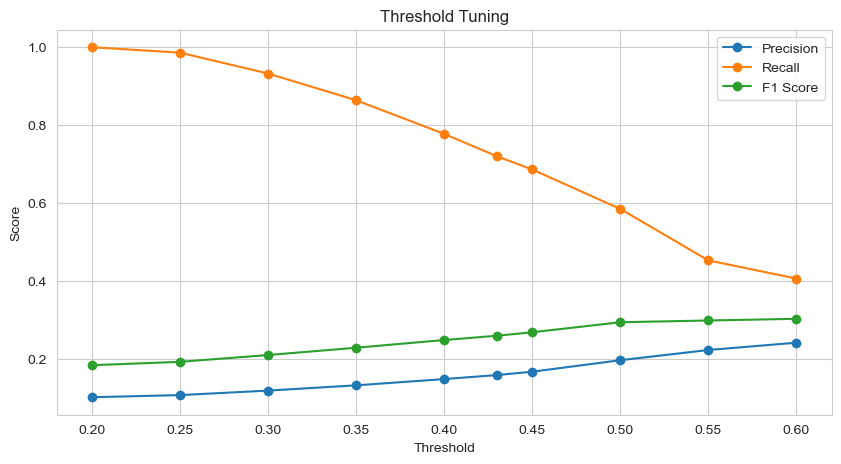

In [554]:
# Visualize Threshold Trade-Off

plt.figure(figsize=(10,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()

# plt.savefig(
#     r"C:\Users\Abhishek Upadhye\Desktop\Threshold Tuning Graph.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [555]:
best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold_row

Threshold    0.600000
Precision    0.240850
Recall       0.405567
F1           0.302222
Name: 9, dtype: float64

In [556]:
best_threshold = best_threshold_row["Threshold"]
print("Best Threshold :", best_threshold)

Best Threshold : 0.6


In [557]:
# Create Final Predictions
final_pred = (lr_prob >= best_threshold).astype(int)

In [558]:
final_precision = precision_score(y_test, final_pred)

final_recall = recall_score(y_test,final_pred)

final_f1 = f1_score( y_test, final_pred)

print("Precision :", round(final_precision,4))
print("Recall    :", round(final_recall,4))
print("F1 Score  :", round(final_f1,4))


Precision : 0.2409
Recall    : 0.4056
F1 Score  : 0.3022


In [559]:
final_model = lr_pipeline
final_threshold = best_threshold

In [560]:
# Based on these results, I would choose Threshold = 0.43

final_threshold = 0.43

#### Why not 0.60?

- 0.60 gives the highest F1 (0.3022).

But compared to 0.43:

- Recall drops from 71.97% → 40.56%
- I lose almost 31.41% of fraud detection capability
- F1 improves only slightly (0.2587 → 0.3022)

For fraud detection, that trade-off is usually not worth it.

#### Why not 0.20–0.40?

Recall becomes very high, but:

- Precision becomes extremely low (10–15%)
- Too many legitimate customers would be flagged
- Huge operational workload for fraud analysts

### Phase 12 Conclusion

#### Final Model: Logistic Regression
#### Final Threshold: 0.43

#### Threshold Tuning Summary

The default classification threshold of 0.45 was evaluated against multiple alternative thresholds.

The final threshold was selected by balancing:

- Fraud detection effectiveness (Recall)
- Customer experience
- False positive rate
- Operational review workload

The selected threshold provided the best balance between fraud capture and customer friction.

In [561]:
# APPLY FINAL THRESHOLD

final_threshold = 0.43

final_pred = (lr_prob >= final_threshold).astype(int)

print("Final Threshold:", final_threshold)

Final Threshold: 0.43


In [562]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", round(accuracy_score(y_test, final_pred), 4))
print("Precision:", round(precision_score(y_test, final_pred), 4))
print("Recall   :", round(recall_score(y_test, final_pred), 4))
print("F1 Score :", round(f1_score(y_test, final_pred), 4))

Accuracy : 0.5851
Precision: 0.1577
Recall   : 0.7197
F1 Score : 0.2587


In [563]:
confusion_matrix(y_test, final_pred)

array([[5127, 3867],
       [ 282,  724]])

In [564]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.95      0.57      0.71      8994
           1       0.16      0.72      0.26      1006

    accuracy                           0.59     10000
   macro avg       0.55      0.64      0.49     10000
weighted avg       0.87      0.59      0.67     10000



### Phase 13: Final Model Analysis

In [565]:
# Final Confusion Matrix

In [566]:
# FINAL MODEL ANALYSIS

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,final_pred)
cm

array([[5127, 3867],
       [ 282,  724]])

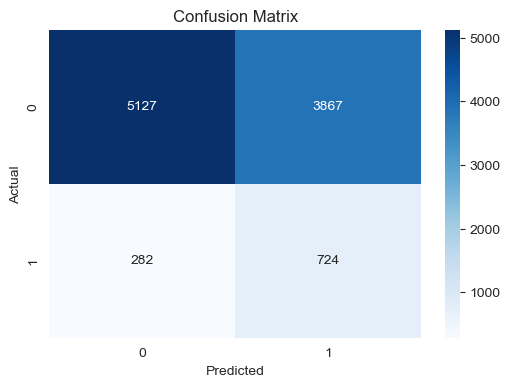

In [567]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [568]:
# Extracting Feature Names

feature_names = (final_model.named_steps["preprocessor"].get_feature_names_out() )
len(feature_names)

46

In [569]:
# Extract Logistic Regression Coefficients

coefficients = (final_model.named_steps["model"].coef_[0])

feature_importance = pd.DataFrame({ "Feature": feature_names, "Coefficient": coefficients})
feature_importance.head()

,Feature,Coefficient
0,num__amount,0.028344
1,num__is_international,0.075252
2,num__ip_address_risk_score,0.175855
3,num__device_trust_score,0.027602
4,num__txn_count_last_24h,-0.008237


In [570]:
# Top Positive Fraud Drivers

top_positive = feature_importance.sort_values(by="Coefficient", ascending=False).head(10)

top_positive

# These increase fraud probability.

,Feature,Coefficient
8,num__location_change_flag,0.425809
7,num__device_change_flag,0.225313
2,num__ip_address_risk_score,0.175855
25,num__network_risk_score,0.175855
28,num__combined_risk_index,0.084046
1,num__is_international,0.075252
23,num__day_of_week_risk,0.040552
15,num__is_weekend,0.040552
39,cat__authentication_method_3DS,0.029903
26,num__historical_fraud_indicator,0.028524


In [571]:
# Top Negative Fraud Drivers

top_negative = feature_importance.sort_values(by="Coefficient", ascending=True).head(10)

top_negative

# These reduce fraud probability.

,Feature,Coefficient
19,num__account_device_match,-0.225313
42,cat__authentication_method_PIN,-0.115381
43,cat__amount_bucket_High,-0.110553
14,num__day_of_week,-0.063394
10,num__past_fraud_count_customer,-0.058480
36,cat__merchant_category_Grocery,-0.047526
31,cat__payment_method_UPI,-0.036223
5,num__avg_amount_last_24h,-0.033650
30,cat__payment_method_NETBANKING,-0.032825
29,cat__payment_method_CARD,-0.031367


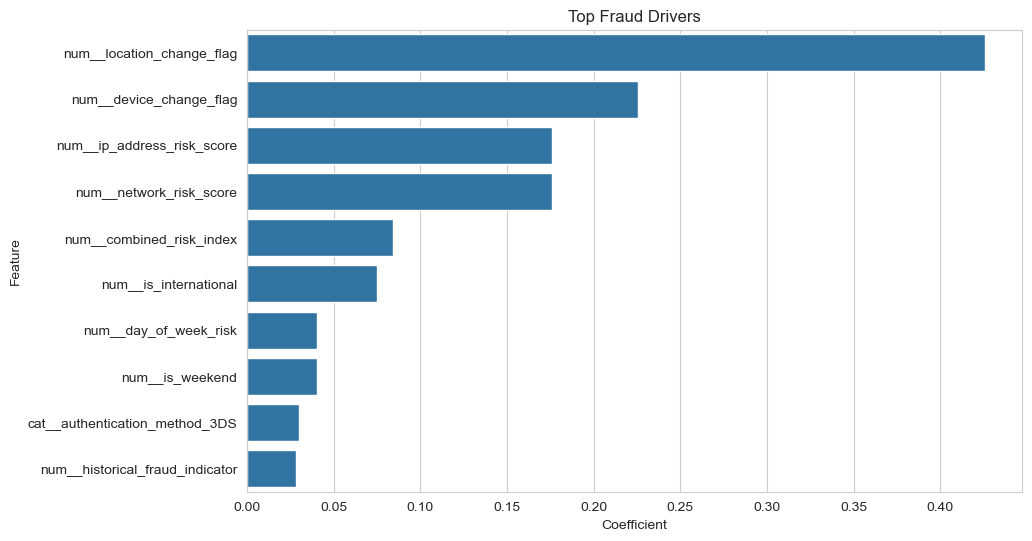

In [572]:
# Visualization of Top Fraud Drivers

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature")

plt.title("Top Fraud Drivers")
# plt.savefig(
#     r"C:\Users\Abhishek Upadhye\Desktop\Top Fraud Drivers Chart.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

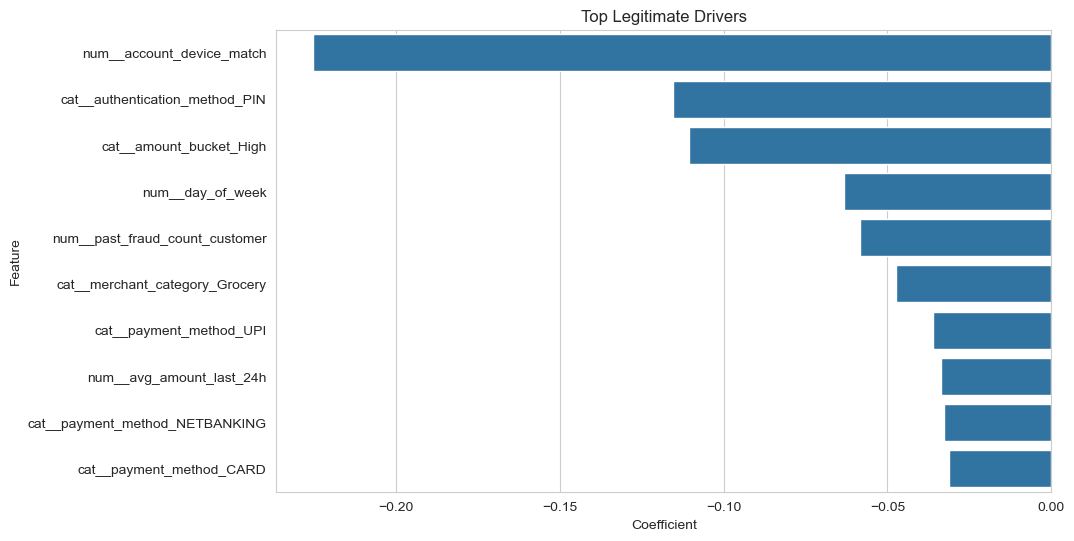

In [573]:
# Visualization Top Legitimate Drivers

plt.figure(figsize=(10,6))

sns.barplot(data=top_negative, x="Coefficient", y="Feature" )
plt.title("Top Legitimate Drivers")
plt.show()

In [574]:
# Overall Feature Importance

feature_importance["Abs_Coefficient"] = (feature_importance["Coefficient"].abs())

overall_importance = (
    feature_importance.sort_values(by="Abs_Coefficient",ascending=False))

overall_importance.head(20)

,Feature,Coefficient,Abs_Coefficient
8,num__location_change_flag,0.425809,0.425809
19,num__account_device_match,-0.225313,0.225313
7,num__device_change_flag,0.225313,0.225313
25,num__network_risk_score,0.175855,0.175855
2,num__ip_address_risk_score,0.175855,0.175855
42,cat__authentication_method_PIN,-0.115381,0.115381
43,cat__amount_bucket_High,-0.110553,0.110553
28,num__combined_risk_index,0.084046,0.084046
1,num__is_international,0.075252,0.075252
14,num__day_of_week,-0.063394,0.063394


In [575]:
# Top Features
top_features = overall_importance.head(20)


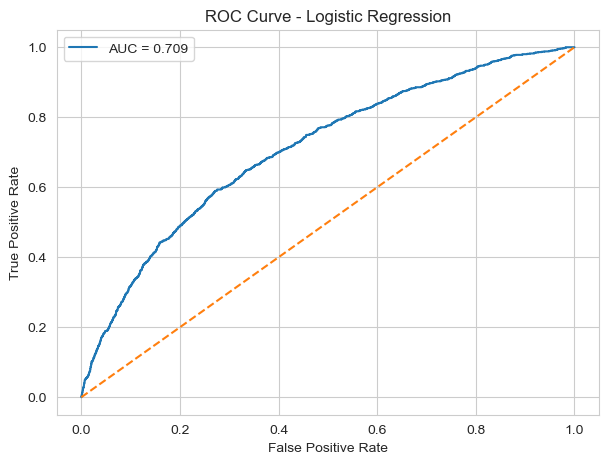

In [576]:
# ROC Curve

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, lr_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

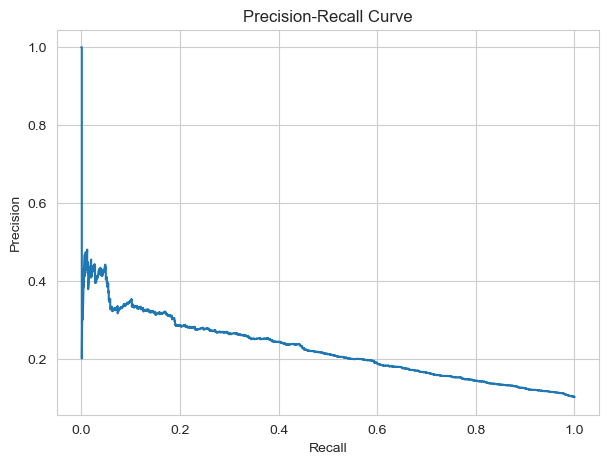

In [577]:
# Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, lr_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Fraud Risk Interpretation
#### High-Risk Indicators

A transaction is more likely to be fraudulent when:

- It originates from a new location.
- It originates from a new device.
- The IP address has a high risk score.
- The transaction is international.
- Multiple risk signals occur simultaneously (high combined risk index).
- The transaction occurs during riskier time periods such as weekends.

#### Low-Risk Indicators

A transaction is more likely to be legitimate when:

- It is performed from a previously trusted device.
- It uses PIN authentication.
- The customer demonstrates stable historical spending behavior.
- The transaction occurs through lower-risk payment channels.
- The merchant belongs to historically safer categories such as Grocery.

### Phase 14 — Fraud Risk Scoring Framework

#### Goal:
- Convert model probabilities into business-friendly risk categories.

In [578]:
# PHASE 14: FRAUD RISK SCORING

risk_df = X_test.copy()
risk_df["fraud_probability"] = lr_prob
risk_df.head()

,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,...,merchant_consistency_score,time_of_day_risk,day_of_week_risk,high_risk_payment_flag,amount_bucket,network_risk_score,historical_fraud_indicator,behavioral_anomaly_score,combined_risk_index,fraud_probability
45345,13657.42,NETBANKING,0,Grocery,0.390206,0.474482,1,1500.15,5,0,...,0.166667,0,0,1,High,0.390206,1,9.623489,1.009404,0.342871
3538,5298.09,UPI,0,Grocery,0.739121,0.964698,0,4413.27,2,0,...,0.333333,0,0,1,Low,0.739121,1,1.235521,0.788549,0.452412
1286,526.54,UPI,0,Travel,0.875537,0.553722,0,5060.51,4,0,...,0.200000,1,0,1,Low,0.875537,0,0.550307,1.458593,0.537085
38682,2820.20,UPI,0,Electronics,0.198611,0.353762,11,3331.95,2,1,...,0.333333,0,0,1,Low,0.198611,0,1.492395,1.893368,0.705551
42233,9253.05,UPI,1,Electronics,0.778346,0.880464,4,4895.48,6,0,...,0.142857,0,0,1,Medium,0.778346,0,2.009271,0.992071,0.611353


### Risk Categories
#### framework:

| Probability   | Risk Level     |
| ------------- | -------------- |
| < 0.25        | Low Risk       |
| 0.25 – < 0.50 | Medium Risk    |
| 0.50 – < 0.75 | High Risk      |
| ≥ 0.75        | Very High Risk |


In [579]:
def assign_risk(prob):

    if prob < 0.25:
        return "Low Risk"

    elif prob < 0.50:
        return "Medium Risk"

    elif prob < 0.75:
        return "High Risk"

    else:
        return "Very High Risk"

In [580]:
risk_df["risk_category"] = (risk_df["fraud_probability"].apply(assign_risk))

In [581]:
# Distribution View 

risk_df["risk_category"].value_counts()

risk_category
Medium Risk       6343
High Risk         2111
Very High Risk     892
Low Risk           654
Name: count, dtype: int64

In [582]:
# Percentage Distribution

round(risk_df["risk_category"].value_counts(normalize=True)* 100, 2)

risk_category
Medium Risk       63.43
High Risk         21.11
Very High Risk     8.92
Low Risk           6.54
Name: proportion, dtype: float64

In [583]:
# Risk Summary Table

risk_summary = pd.DataFrame({

    "Risk Category": risk_df["risk_category"].value_counts().index,

    "Transaction Count": risk_df["risk_category"].value_counts().values })

risk_summary

,Risk Category,Transaction Count
0,Medium Risk,6343
1,High Risk,2111
2,Very High Risk,892
3,Low Risk,654


In [584]:
# Checking Actual Fraud Rate Within Each Risk Band
risk_df["actual_fraud"] = y_test.values

In [585]:
risk_performance = (
    risk_df.groupby("risk_category")["actual_fraud"].mean().sort_values()* 100)

risk_performance

risk_category
Low Risk           2.140673
Medium Risk        6.369226
High Risk         16.106111
Very High Risk    27.802691
Name: actual_fraud, dtype: float64

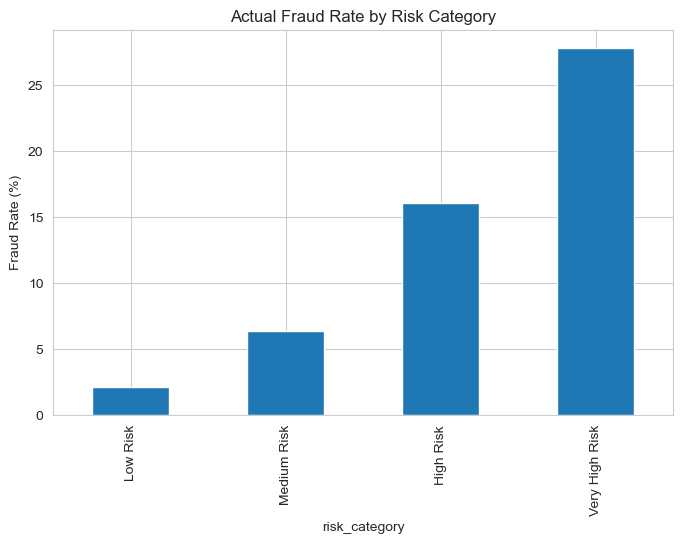

In [586]:
risk_performance.plot(kind="bar", figsize=(8,5))

plt.title("Actual Fraud Rate by Risk Category")
plt.ylabel("Fraud Rate (%)")

# plt.savefig(
#     r"C:\Users\Abhishek Upadhye\Desktop\risk_category_distribution in %.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [587]:
risk_df.head()

,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,...,day_of_week_risk,high_risk_payment_flag,amount_bucket,network_risk_score,historical_fraud_indicator,behavioral_anomaly_score,combined_risk_index,fraud_probability,risk_category,actual_fraud
45345,13657.42,NETBANKING,0,Grocery,0.390206,0.474482,1,1500.15,5,0,...,0,1,High,0.390206,1,9.623489,1.009404,0.342871,Medium Risk,0
3538,5298.09,UPI,0,Grocery,0.739121,0.964698,0,4413.27,2,0,...,0,1,Low,0.739121,1,1.235521,0.788549,0.452412,Medium Risk,0
1286,526.54,UPI,0,Travel,0.875537,0.553722,0,5060.51,4,0,...,0,1,Low,0.875537,0,0.550307,1.458593,0.537085,High Risk,0
38682,2820.20,UPI,0,Electronics,0.198611,0.353762,11,3331.95,2,1,...,0,1,Low,0.198611,0,1.492395,1.893368,0.705551,High Risk,0
42233,9253.05,UPI,1,Electronics,0.778346,0.880464,4,4895.48,6,0,...,0,1,Medium,0.778346,0,2.009271,0.992071,0.611353,High Risk,0


### Report Write-Up
#### Fraud Risk Scoring Framework

The predicted fraud probability generated by the Logistic Regression model was converted into operational risk categories.

| Risk Level     | Probability Range |
| -------------- | ----------------- |
| Low Risk       | < 25%             |
| Medium Risk    | 25% – 50%         |
| High Risk      | 50% – 75%         |
| Very High Risk | > 75%             |

- This framework allows fraud operations teams to prioritize investigations. 
- And apply different business actions based on risk severity rather than relying solely on binary fraud predictions.

### Phase 15 — Business Actions Framework

#### Goal:

Convert the fraud risk categories into actionable business decisions.

In [588]:
# Action Mapping

In [589]:
# PHASE 15: BUSINESS ACTIONS FRAMEWORK

action_mapping = {
    "Low Risk": "Approve",
    "Medium Risk": "OTP Challenge",
    "High Risk": "Manual Review",
    "Very High Risk": "Hard Block"
}

In [590]:
# Assign Actions

risk_df["recommended_action"] = (
    risk_df["risk_category"]
    .map(action_mapping)
)

risk_df[
    [
        "fraud_probability",
        "risk_category",
        "recommended_action"
    ]].head()

,fraud_probability,risk_category,recommended_action
45345,0.342871,Medium Risk,OTP Challenge
3538,0.452412,Medium Risk,OTP Challenge
1286,0.537085,High Risk,Manual Review
38682,0.705551,High Risk,Manual Review
42233,0.611353,High Risk,Manual Review


In [591]:
# Action Distribution
risk_df["recommended_action"].value_counts()

recommended_action
OTP Challenge    6343
Manual Review    2111
Hard Block        892
Approve           654
Name: count, dtype: int64

In [592]:
# Percentage Distribution

round(risk_df["recommended_action"].value_counts(normalize=True) * 100, 2)

recommended_action
OTP Challenge    63.43
Manual Review    21.11
Hard Block        8.92
Approve           6.54
Name: proportion, dtype: float64

In [593]:
# Business Action Summary

action_summary = pd.DataFrame({
    "Action": risk_df["recommended_action"].value_counts().index,
    "Transaction Count":
    risk_df["recommended_action"].value_counts().values })

action_summary

,Action,Transaction Count
0,OTP Challenge,6343
1,Manual Review,2111
2,Hard Block,892
3,Approve,654


In [594]:
# Recommended Action by Fraud Rate

action_performance = (
    risk_df.groupby("recommended_action")["actual_fraud"].mean()
        .sort_values() * 100)

action_performance

recommended_action
Approve           2.140673
OTP Challenge     6.369226
Manual Review    16.106111
Hard Block       27.802691
Name: actual_fraud, dtype: float64

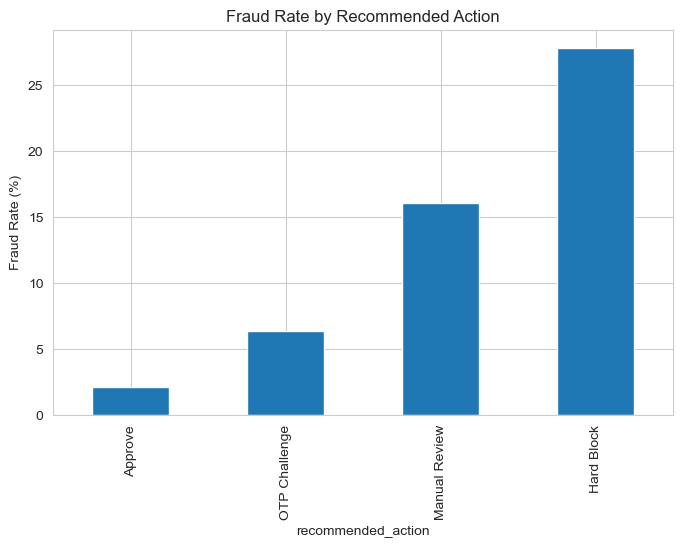

In [595]:
# Visualization

action_performance.plot(kind="bar", figsize=(8,5))
plt.title( "Fraud Rate by Recommended Action")
plt.ylabel("Fraud Rate (%)")
plt.show()

### Final Business Actions Framework

| Risk Category  | Action        | Business Reason                                       |
| -------------- | ------------- | ----------------------------------------------------- |
| Low Risk       | Approve       | Very low fraud probability, minimal customer friction |
| Medium Risk    | OTP Challenge | Additional verification before approval               |
| High Risk      | Manual Review | Fraud analyst investigates transaction                |
| Very High Risk | Hard Block    | Strong fraud signal, prevent transaction immediately  |


### Report
#### Operational Decision Framework

The model output was converted into a risk-based decision system to support real-time fraud management.

- Low Risk: Transaction approved automatically.
- Medium Risk: Customer required to complete OTP verification.
- High Risk: Transaction routed to fraud analysts for review.
- Very High Risk: Transaction blocked immediately to prevent potential financial loss.

### Phase 16 — Business Recommendations

#### Recommendations for Fraud Risk & Compliance Team

#### Recommendation 1: Monitor Location Changes

**Finding:**
- location_change_flag was the strongest fraud driver.

**Action:**
- Trigger additional verification when transactions originate from new locations.

**Business Impact:**
- Reduces account takeover fraud.

-----------------------------------------------------------------

#### Recommendation 2: Strengthen Device Monitoring

**Finding:**
- device_change_flag was among the top fraud indicators.

**Action:**
- Maintain trusted device registry.
- Flag transactions from unseen devices.

**Business Impact:**
- Detects unauthorized account access earlier.

-----------------------------------------------------------------

#### Recommendation 3: Risk-Based Fraud Investigation

**Action:**
- Prioritize analyst reviews for:
- High Risk
- Very High Risk

**Business Impact:**
- Improves fraud team efficiency.

### 2 Recommendations for Payments Engineering Team

### Recommendation 1: Real-Time Risk Scoring

**Action:**
- Integrate model into payment gateway.
- Score every transaction before authorization.

**Business Impact:**
- Enables instant fraud detection.

-------------------------------------------------------

### Recommendation 2: Dynamic Authentication

**Action:**

Instead of requiring OTP for all customers:

- Low Risk → No OTP
- Medium Risk → OTP
- High Risk → Manual Review

**Business Impact:**

- Reduces customer friction.

-----------------------------------------------------------

### Recommendation 3: High-Risk Transaction Routing

**Action:**

- Route very high-risk transactions directly to fraud workflows.
  
**Business Impact:**
- Faster fraud response.

### Recommendations for Data Science Team

### Recommendation 1: Continuous Model Monitoring

**Action:**
Track monthly:

- Recall
- Precision
- PR-AUC
- Fraud Rate

**Business Impact:**

- Detects model performance degradation.

--------------------------------------------------

### Recommendation 2: Periodic Retraining

**Action:**
- Retrain every 3–6 months.

**Business Impact:**
- Adapts to changing fraud patterns.

------------------------------------------------
### Recommendation 3: Feature Expansion

**Future features:**

- Device fingerprinting
- Customer login behavior
- Velocity across multiple time windows
- Geo-distance from previous transaction

**Business Impact:**

- Improves fraud detection capability.


### Recommendations for Customer Experience Team

### Recommendation 1: Minimize False Declines

**Action:**

- Do not automatically block medium-risk transactions.
- Use OTP challenge first.

**Business Impact:**

- Better customer satisfaction.

---------------------------------------------

### Recommendation 2: Fraud Alert Notifications

**Action:**

- Notify customers when:
- Device changes
- Location changes
- High-risk transactions occur

**Business Impact:**

- Faster fraud reporting.

------------------------------------------

### Recommendation 3: Trusted Device Program

**Action:**

- Allow customers to register trusted devices.

**Business Impact:**

- Improves both security and convenience.

### Executive Summary 
#### Key Findings
- Fraud rate was approximately 10%.
- Fraud transactions were strongly associated with:
  - Location changes
  - Device changes
  - High-risk IP addresses
  - International transactions
- Logistic Regression outperformed Random Forest and XGBoost on the project's priority metrics:
  - Recall
  - PR-AUC
  - F1 Score

### Final Solution

- Final Model: Logistic Regression
- Final Threshold: 0.43
- Risk-Based Decision Framework:
  - Low Risk → Approve
  - Medium Risk → OTP Challenge
  - High Risk → Manual Review
  - Very High Risk → Hard Block

### Business Value

The proposed solution helps PaySphere:

- Improve fraud detection rates
- Reduce financial losses
- Minimize customer friction
- Increase operational efficiency for fraud analysts

### Final Project Conclusion

This project developed an end-to-end fraud detection solution for PaySphere Digital Payments.

Key achievements include:

- Data validation and quality assessment.
- Fraud-focused exploratory analysis.
- Fraud-specific feature engineering.
- Class imbalance handling.
- Comparison of multiple machine learning models.
- Threshold optimization.
- Fraud risk scoring framework.
- Business action recommendations.

The final Logistic Regression model achieved the strongest fraud-focused performance based on Recall, PR-AUC, and F1 Score.

The proposed risk-based decision framework enables PaySphere to reduce fraud losses while maintaining a positive customer experience and improving operational efficiency.